1. Wstęp i Opis Algorytmu

Regresja liniowa to jedna z podstawowych metod statystycznego uczenia maszynowego, służąca do modelowania relacji między zmienną zależną (celu) y, a jedną lub wieloma zmiennymi objaśniającymi (cechami) X. W kontekście analizy zbioru Heart Disease, algorytm ten posłuży do oszacowania prawdopodobieństwa wystąpienia schorzenia na podstawie parametrów medycznych pacjenta.
Mechanizm działania algorytmu

Istotą regresji liniowej jest wyznaczenie funkcji liniowej, która najlepiej opisuje trend widoczny w danych. Proces ten opiera się na metodzie najmniejszych kwadratów (Ordinary Least Squares). Algorytm dąży do zminimalizowania sumy kwadratów błędów (SSE – Sum of Squared Errors), czyli sumy kwadratów różnic między rzeczywistymi wartościami z zestawu treningowego a wartościami przewidzianymi przez model. Dzięki temu linia regresji zostaje poprowadzona w taki sposób, aby błąd predykcji dla całego zbioru był jak najniższy.

Kluczowe parametry modelu w bibliotece Scikit-learn:

W eksperymentach wykorzystano klasę LinearRegression z następującymi parametrami:
 - fit_intercept (Stała/Punkt przecięcia):
   - Parametr ten określa, czy model powinien obliczać wyraz wolny (intercept), czyli punkt przecięcia prostej z osią Y.
   - Zastosowanie: W większości przypadków medycznych ustawiamy wartość True, ponieważ rzadko zakładamy, że przy zerowych wartościach cech wynik również musi wynosić zero.
 - copy_X (Kopiowanie danych)
   - Określa, czy algorytm ma operować na oryginalnej macierzy danych, czy na jej kopii.
   - Zastosowanie: Ustawienie True (domyślne) jest bezpieczniejsze z punktu widzenia integralności danych, gdyż zapobiega nadpisywaniu oryginalnych zmiennych podczas obliczeń macierzowych wykonywanych przez bibliotekę.

2. Import Bibliotek i Ładowanie Danych

Zbiór Heart Disease z UCI często ma brakujące wartości oznaczone jako ?

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, roc_curve, auc, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
 
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 
           'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data', 
                 names=columns, na_values='?')

3. Analiza Danych

--- Braki danych ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

--- Podstawowe statystyki ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


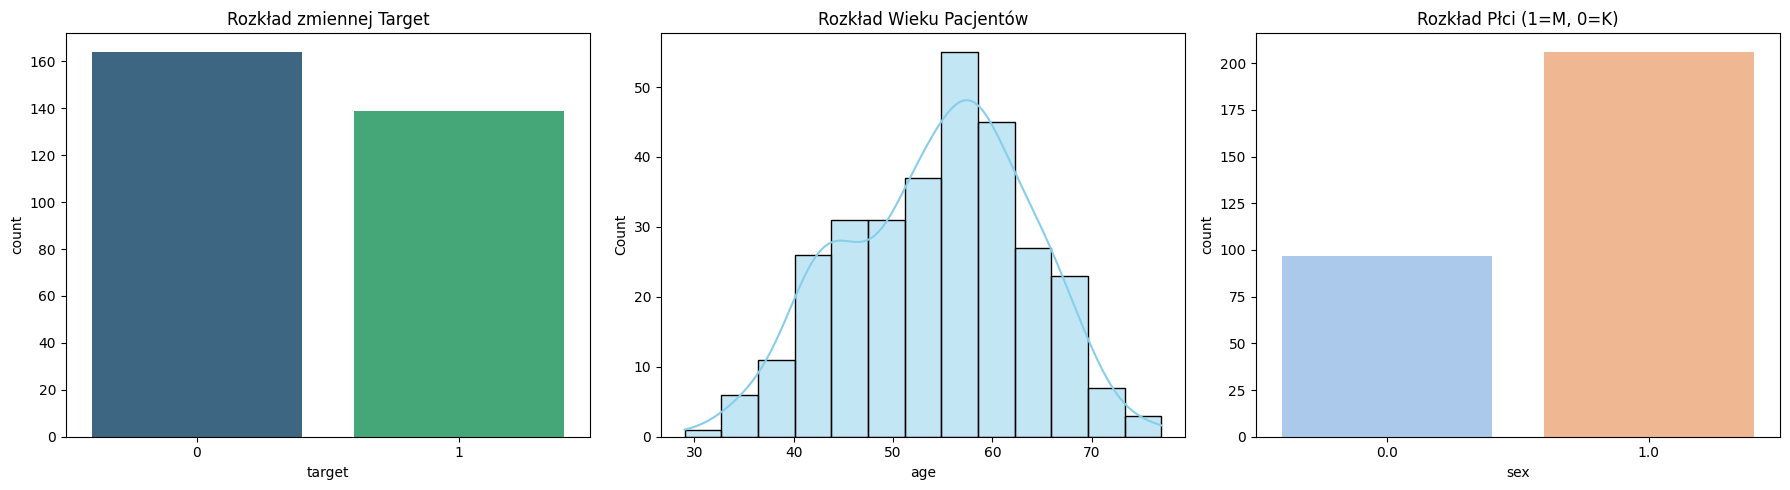

In [19]:
def analyze_data(data):
    print("--- Braki danych ---")
    print(data.isnull().sum())
    
    print("\n--- Podstawowe statystyki ---")
    display(data.describe())
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.countplot(x='target', data=data, ax=axes[0], palette='viridis', hue='target', legend=False)
    axes[0].set_title('Rozkład zmiennej Target')
    
    sns.histplot(data['age'], kde=True, ax=axes[1], color='skyblue')
    axes[1].set_title('Rozkład Wieku Pacjentów')
    
    sns.countplot(x='sex', data=data, ax=axes[2], palette='pastel', hue='sex', legend=False)
    axes[2].set_title('Rozkład Płci (1=M, 0=K)')
    
    plt.tight_layout()
    plt.show()

analyze_data(df)

Wnioski z przeprowadzonej analizy:

- Brakujące dane: Analiza wykazała obecność brakujących wartości w dwóch cechach: `ca` (4 braki) oraz `thal` (2 braki). Łącznie stanowi to niewielki odsetek zbioru (ok. 2%), co pozwala na zastosowanie imputacji (uzupełnienia danych) bez ryzyka znaczącego zniekształcenia wyników.
- Rozkład zmiennej Target: Wykres pokazuje, że zbiór jest niezbalansowany. Najliczniejszą grupę stanowią osoby zdrowe (kategoria 0 – ponad 160 przypadków). Pozostałe kategorie (1-4) reprezentują chorych. W kolejnym kroku dokonamy binarizacji tej zmiennej, aby umożliwić regresji liniowej     pracę na dwóch klasach (zdrowy/chory).
- Demografia (Wiek i Płeć):**
  - Rozkład wieku jest zbliżony do rozkładu normalnego, z wyraźnym szczytem w przedziale **55-65 lat**. Sugeruje to, że dane dotyczą głównie osób w wieku średnim i starszym.
  - W zbiorze występuje znacząca przewaga mężczyzn (kod `1.0`) nad kobietami (kod `0.0`). Ta dysproporcja jest istotna, ponieważ płeć może być ważnym czynnikiem ryzyka w modelu.
- Statystyki opisowe: Średnie ciśnienie krwi (`trestbps`) wynosi ok. 131 mmHg, a średni poziom cholesterolu (`chol`) to 246 mg/dl, co wskazuje na to, że badana grupa pacjentów faktycznie znajduje się w grupie ryzyka chorób serca.

4. Radzenie sobie z brakami i kategorycznością

W tej sekcji przygotowujemy surowe dane do pracy z modelem regresji liniowej. Wykonujemy trzy kluczowe operacje:

4.1. Binarizacja zmiennej docelowej
Oryginalny zbiór zawiera stopnie choroby od 0 do 4. Ponieważ naszym celem jest klasyfikacja (zdrowy vs chory) oraz wygenerowanie krzywej ROC, mapujemy wartości:
 - 0 -> 0 (brak choroby)
 - 1, 2, 3, 4 -> 1 (obecność choroby)

4.2. Imputacja brakujących danych
Wcześniejsza analiza wykazała braki w kolumnach ca oraz thal. Używamy klasy SimpleImputer ze strategią mediany. Wybraliśmy medianę, ponieważ jest ona bardziej odporna na wartości odstające niż średnia, co jest istotne w danych medycznych.

4.3. Kodowanie zmiennych kategorycznych (One-Hot Encoding)
To najważniejszy krok dla modelu liniowego. Zmienne takie jak ból w klatce piersiowej (cp) czy wynik EKG (restecg) są zapisane jako liczby (np. 1, 2, 3), ale te liczby nie oznaczają, że kategoria "3" jest większa lub ważniejsza od "1". Są to tylko etykiety.

In [14]:
def preprocess_heart_data(data):
    df_temp = data.copy()
    
    df_temp['target'] = df_temp['target'].apply(lambda x: 1 if x > 0 else 0)
    
    X = df_temp.drop('target', axis=1)
    y = df_temp['target']
    
    imputer = SimpleImputer(strategy='median')
    X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    
    X_final = pd.get_dummies(X_imputed, columns=['cp', 'restecg', 'slope', 'thal'], drop_first=True)
    
    return X_final, y

# Wywołanie
X, y = preprocess_heart_data(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
5. Eksperymenty i Modelowanie

W tej sekcji przeprowadzimy proces trenowania modelu Regresji Liniowej. Chociaż model ten służy zazwyczaj do przewidywania wartości ciągłych, w naszym przypadku wykorzystamy go jako klasyfikator prawdopodobieństwa.

Algorytm w kontekście zadania:
Model regresji wylicza wagi dla każdej cechy, dążąc do zminimalizowania błędu kwadratowego. Wynik modelu (ypred​) może przyjmować wartości wykraczające poza zakres [0, 1], jednak wciąż można go interpretować jako "wskaźnik pewności" wystąpienia choroby. Im wyższa wartość, tym większe prawdopodobieństwo, że pacjent jest chory.

Opis Eksperymentu: Wpływ standaryzacji (scaling)

W ramach eksperymentu sprawdzimy, jak standaryzacja cech wpływa na wyniki.

 - Standaryzacja (StandardScaler) sprowadza wszystkie cechy do wspólnej skali (średnia = 0, odchylenie standardowe = 1).
 - Jest to istotne, ponieważ bez skalowania cechy o dużych zakresach (np. cholesterol osiągający 500) mogłyby zdominować cechy o małych zakresach (np. sex 0-1), co utrudnia interpretację wag modelu.

In [16]:
def run_experiment(X_tr, X_te, y_tr, y_te, scale=True):
    if scale:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)
    
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    return y_te, preds

# Eksperyment 1: Dane przeskalowane
y_test_exp1, y_pred_exp1 = run_experiment(X_train, X_test, y_train, y_test, scale=True)

# Eksperyment 2: Dane surowe (bez skalowania)
y_test_exp2, y_pred_exp2 = run_experiment(X_train, X_test, y_train, y_test, scale=False)

In [ ]:
6. Wizualizacja i Krzywa ROC

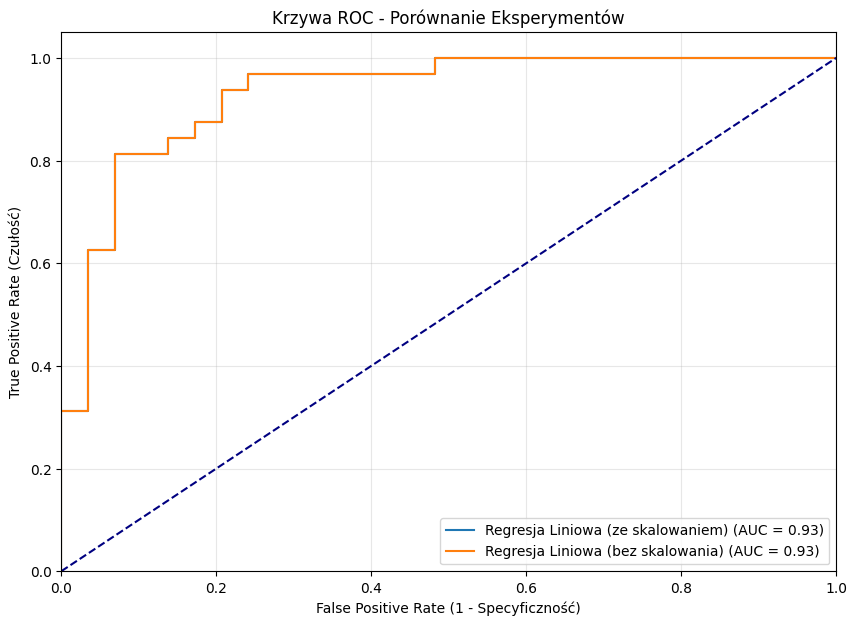

In [17]:
def plot_roc_comparison(results):
    plt.figure(figsize=(10, 7))
    
    for name, y_true, y_pred in results:
        fpr, tpr, _ = roc_curve(y_true, y_pred)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specyficzność)')
    plt.ylabel('True Positive Rate (Czułość)')
    plt.title('Krzywa ROC - Porównanie Eksperymentów')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

experiments = [
    ('Regresja Liniowa (ze skalowaniem)', y_test_exp1, y_pred_exp1),
    ('Regresja Liniowa (bez skalowania)', y_test_exp2, y_pred_exp2)
]
plot_roc_comparison(experiments)

7. Wnioski
- Jakość modelu: Wynik AUC = 0.93 potwierdza wysoką skuteczność predykcyjną. Kształt krzywej ROC wskazuje na bardzo dobrą przydatność modelu w diagnostyce medycznej.
- Wnioski z eksperymentu: Standaryzacja danych nie zmieniła wyniku AUC. Potwierdza to teorię, że w regresji liniowej transformacje tego typu nie wpływają na końcową jakość klasyfikacji.
- Podsumowanie: Regresja liniowa efektywnie ocenia ryzyko choroby dzięki binarnej transformacji zmiennej celu oraz zastosowaniu kodowania One-Hot Encoding dla cech kategorycznych.